# DATA5000 Workshop #2 Notebook on Forecasting

# ***NeuralProphet:***

## https://neuralprophet.com/

# ***Presentation***
## https://github.com/ourownstory/neural_prophet/blob/main/notes/NeuralProphet_Introduction.pdf

### ***The research paper:***
## https://arxiv.org/abs/2111.15397

### ***Facebook Prophet***, which set an industry standard for explainable, scalable, and user-friendly forecasting frameworks: https://facebook.github.io/prophet/

### But Prophet is a statistical method - NOT a Neural Network-based Model.

### ***Prophet*** also lacks understanding of "local context": which is essential for forecasting the near-term future.

### The lack of local context, which is essential for forecasting the near-term future, has restricted the usefulness of Prophet in industrial applications.


### ***Readings***:

* https://towardsdatascience.com/in-depth-understanding-of-neuralprophet-through-a-complete-example-2474f675bc96

* https://towardsdatascience.com/prophet-vs-neuralprophet-fc717ab7a9d8


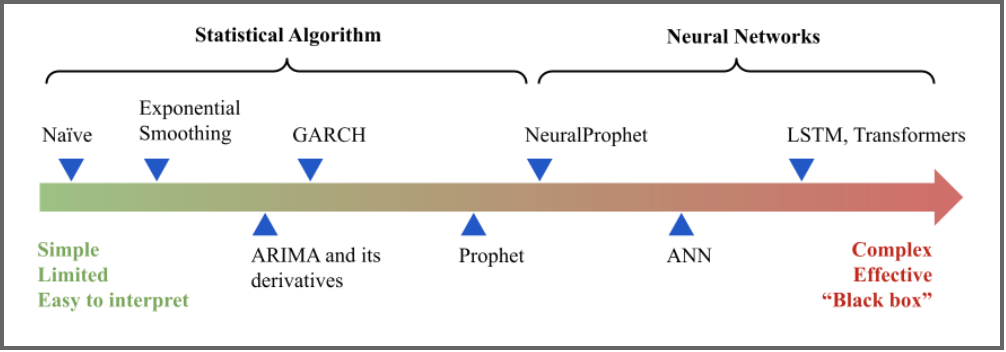

#***LOCAL CONTEXT***

### ***A local context is:*** the near-term future depends on the current state of the system. The majority of time series forecasting exhibits those dynamics, evidenced in scenarios related to energy consumption, traffic patterns, air quality measures, and much more. For example, when there’s a strong uptick in server load, it might have been triggered by a recent event that could continue for prolonged periods, which should be reflected in near-term forecasts.

### For short to medium-term forecasts, NeuralProphet improves forecast accuracy by 55 to 92 percent.

# ***TIME IN NEURAL PROPHET***
### Pandas Time Series: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#timeseries-offset-aliases

#***What is a Neural Network?***
## What is a Neural Network? https://www.ibm.com/cloud/learn/neural-networks

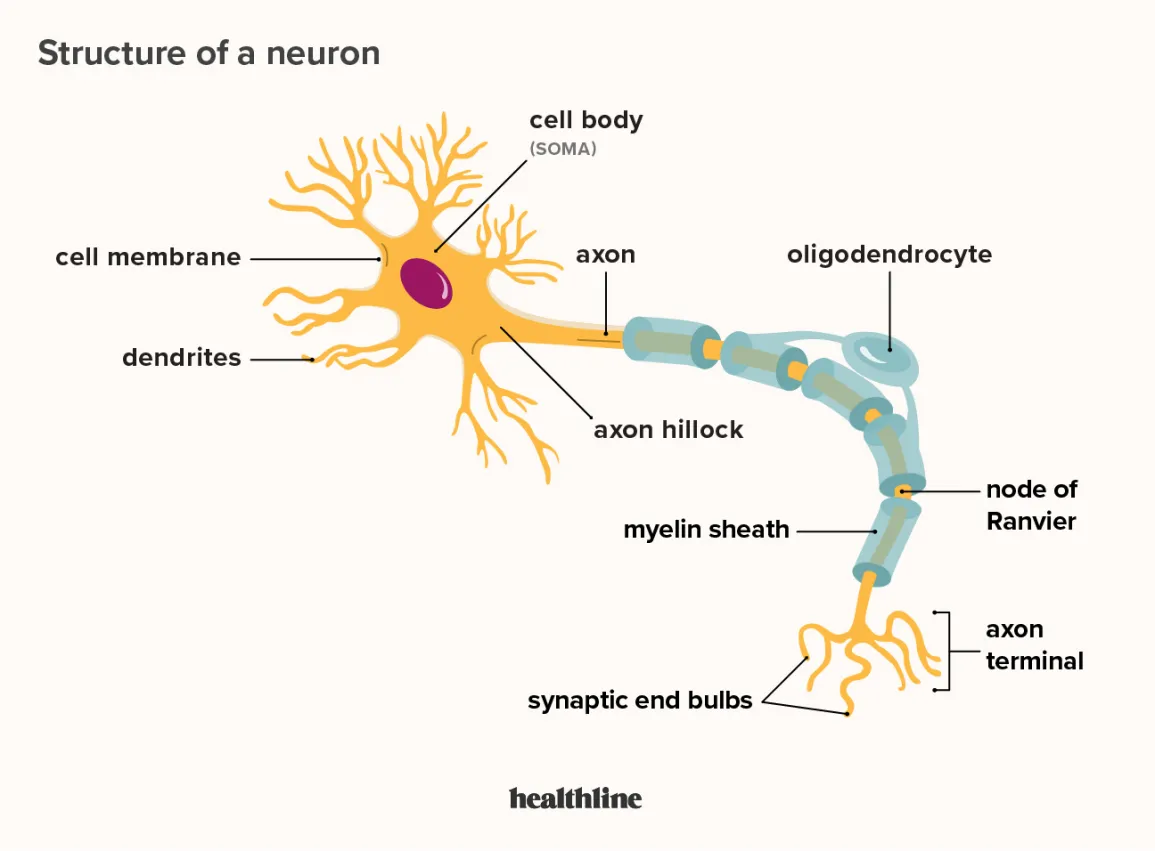

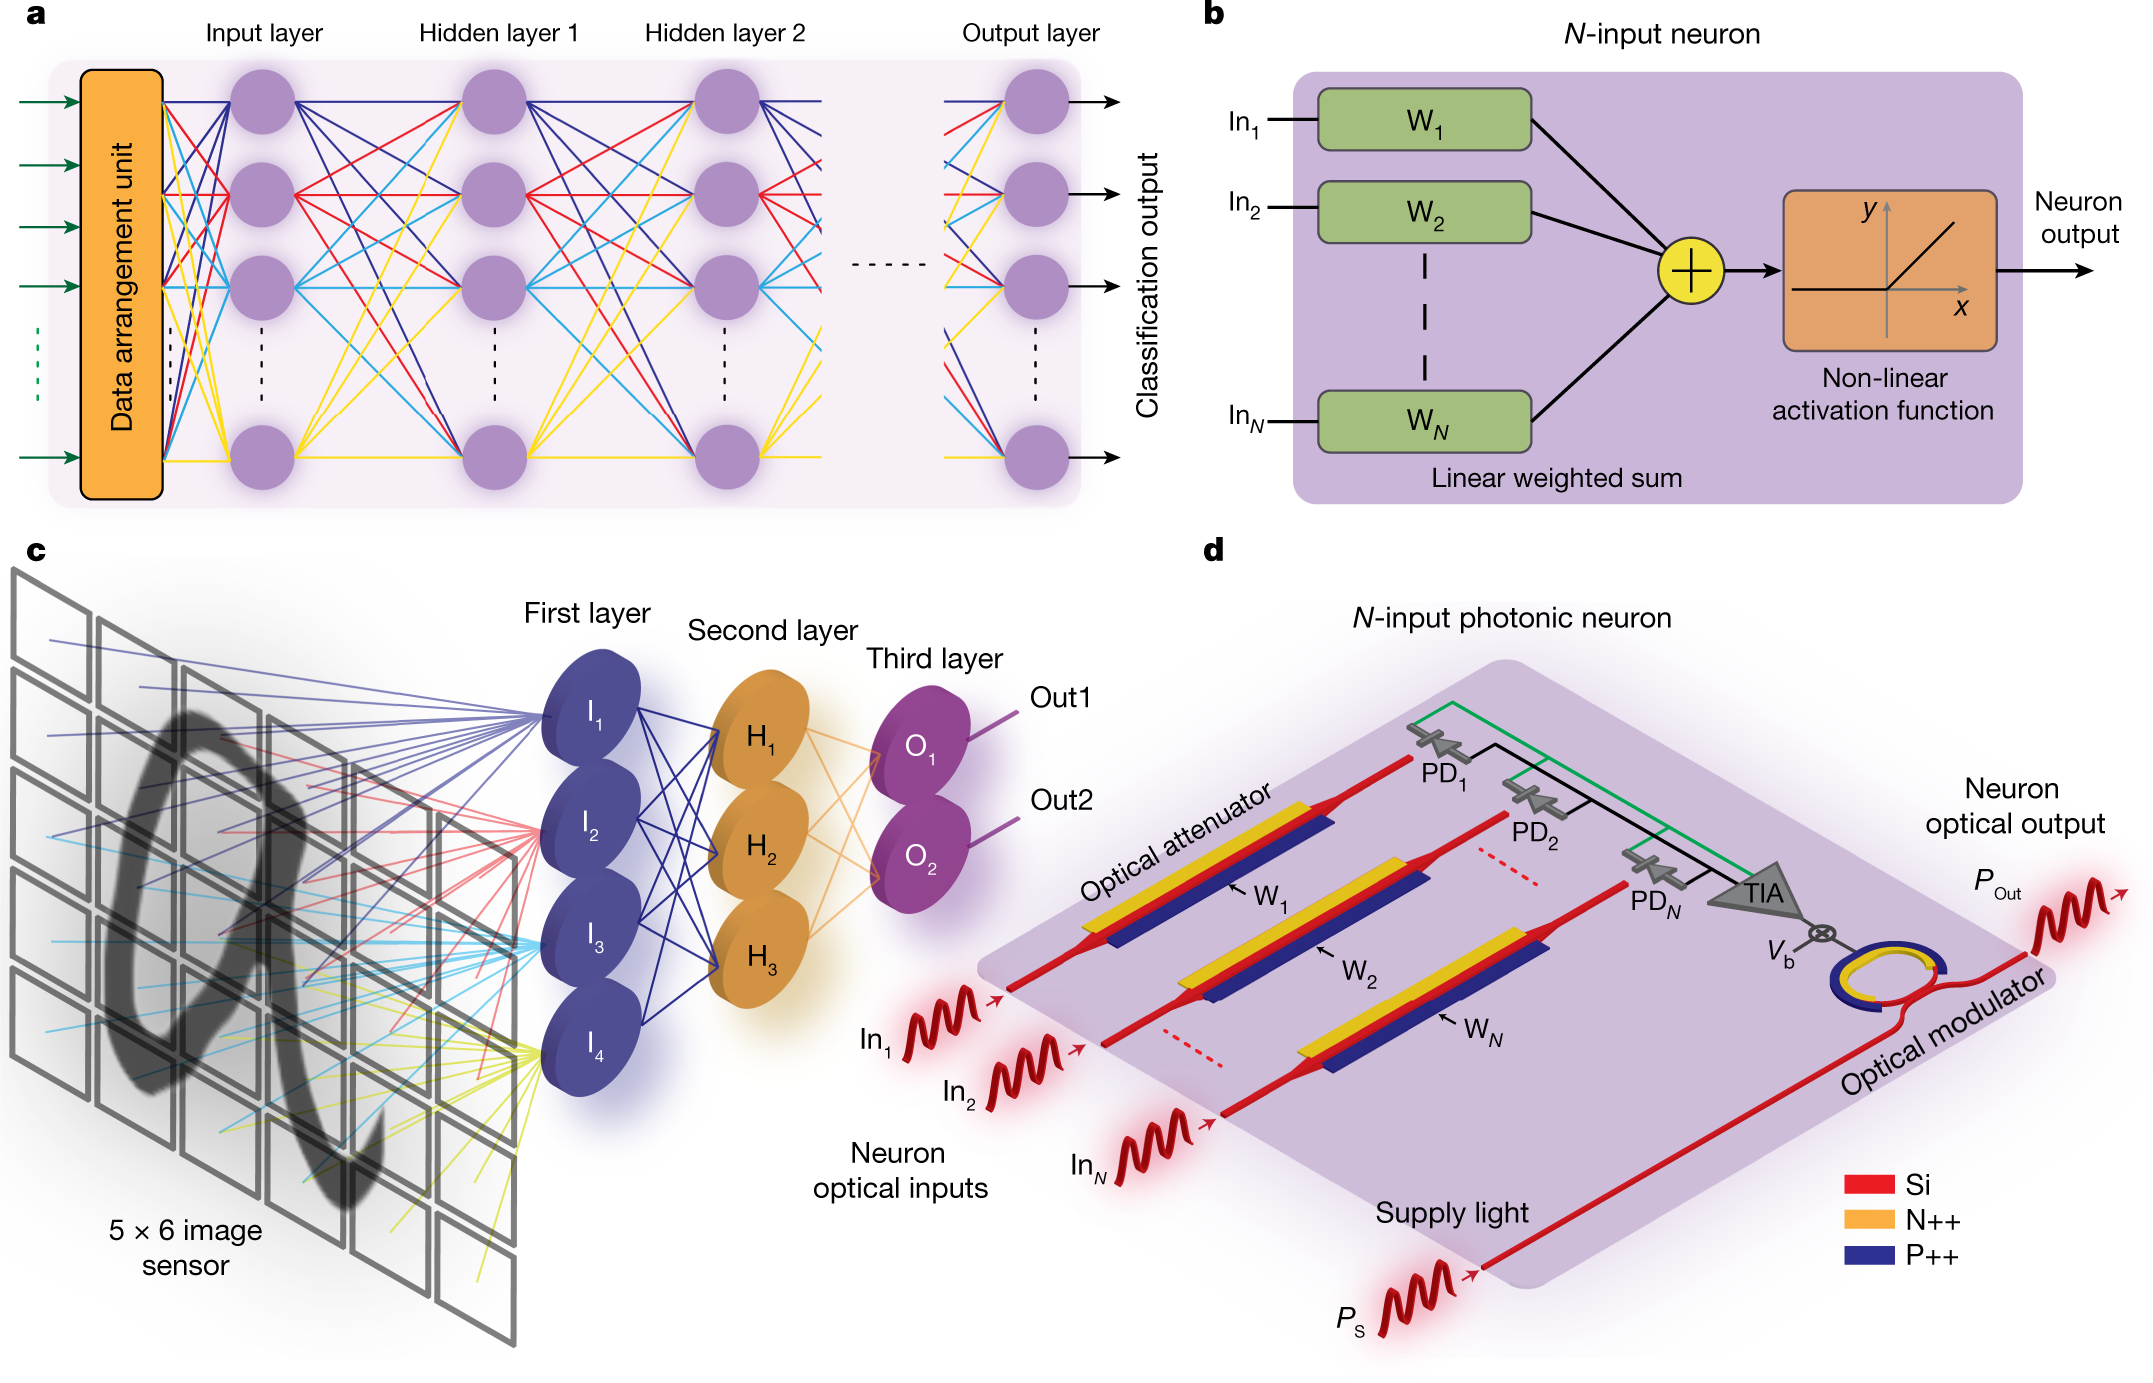

# ***Running NeuralProphet***

In [1]:
import sys
sys.version

'3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]'

# STEP 1: Install Libraries

**NOTE:** If you get the message "You must restart the runtime in order to use newly installed versions," _please do so._

We start by uninstalling everything that won't work with NeuralProphet.

In [2]:
!pip uninstall -y tensorflow torch torchvision torchaudio opencv-python numpy pandas opencv-contrib-python opencv-python-headless albucore pil albumentations dopamine-rl captum numba datasets gcsfs gradio neuralprophet librosa pytensor stumpy cuml-cu12 torchtune segregation bigframes tensorflow-decision-forests shap cudf-cu12 quantecon pynndescent umap-learn torchmetrics pytorch-lightning tsfresh dask-cudf-cu12 sentence-transformers pysal pymc accelerate peft giddy jax rasterio tobler jaxlib pil markupsafe networkx flax orbax-checkpoint optax chex splot rasterstats fastai

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: opencv-contrib-python 4.12.0.88
Uninstalling opencv-contrib-python-4.12.0.88:
  Su

In [3]:
!pip install --no-cache-dir --force-reinstall numpy==1.26.4 pandas==2.2.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 326.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 293.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 443.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.2/509.2 kB 410.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.5/348.5 kB 402.3 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: tzdata
    Found existing installation: tzdata 2025.3
    Uninstalling tzdata-2025.3:
      Successfully uninstalled tzdata-2025.3
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: python-dateutil
    Found existing installation:

In [1]:
!pip install --no-cache-dir --force-reinstall --pre torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 222.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 314.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 178.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 322.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 199.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 268.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 257.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 225.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 176.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 49.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 200.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [1]:
!pip install --no-cache-dir --pre neuralprophet==1.0.0rc10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.2/148.2 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 229.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 302.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.5/255.5 kB 311.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 340.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 466.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 450.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.0rc1
    Uninstalling numpy-2.4.0rc1:
      Successfully uninstalled numpy-2.4.0rc1


In [1]:
# remove superfluous NeuralProphet warnings
import logging
import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*Series\.view is deprecated.*",
)
warnings.filterwarnings(
    "ignore",
    message=r".*Trying to infer the `batch_size` from an ambiguous collection.*",
)
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=r".*Series\.view is deprecated.*",
)
logging.getLogger("py.warnings").setLevel(logging.ERROR)
logging.getLogger("NP.plotly").setLevel(logging.CRITICAL)

### Import installed libraries

In [2]:
from neuralprophet import NeuralProphet, set_log_level
set_log_level("ERROR")

In [3]:
import neuralprophet
import torch

In [4]:
import pandas as pd
import matplotlib
import matplotlib_inline
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

In [5]:
(np.__version__, pd.__version__, torch.__version__, neuralprophet.__version__)

('1.26.4', '2.2.2', '2.3.1+cu121', '1.0.0rc10')

#STEP 2: Basic NeuralProphet on Test Data

In [6]:
data_location = "https://raw.githubusercontent.com/ourownstory/neuralprophet-data/main/datasets/"
df = pd.read_csv(data_location + "wp_log_peyton_manning.csv", dayfirst=True)

In [7]:
df

,ds,y
0,2007-12-10,9.5908
1,2007-12-11,8.5196
2,2007-12-12,8.1837
3,2007-12-13,8.0725
4,2007-12-14,7.8936
...,...,...
2959,2016-01-16,7.8172
2960,2016-01-17,9.2739
2961,2016-01-18,10.3338
2962,2016-01-19,9.1259


# Create NeuralProphet

In [8]:
# epochs - how many generations to learn
example_model = NeuralProphet(quantiles=[0.02, 0.98], epochs=10)

# Model training - make sure that the frequency of the time series is correctly coded

In [9]:
example_model_metrics = example_model.fit(df, freq="D", progress='plot-all')

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/237 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

In [10]:
example_model_future = example_model.make_future_dataframe(df, periods=365, n_historic_predictions=True)

In [11]:
example_model_forecast = example_model.predict(example_model_future)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [12]:
example_model_forecast

,ds,y,yhat1,yhat1 2.0%,yhat1 98.0%,trend,season_yearly,season_weekly
0,2007-12-10,9.5908,8.158774,6.131753,9.976610,7.460659,0.368976,0.329140
1,2007-12-11,8.5196,7.943749,3.580609,9.176916,7.461761,0.365465,0.116523
2,2007-12-12,8.1837,7.761433,5.823930,8.842075,7.462865,0.363208,-0.064639
3,2007-12-13,8.0725,7.770940,6.057343,8.881071,7.463968,0.362263,-0.055290
4,2007-12-14,7.8936,7.760506,5.983233,8.949816,7.465071,0.362867,-0.067432
...,...,...,...,...,...,...,...,...
3324,2017-01-15,NaN,8.508204,7.181949,9.072968,7.418885,1.039355,0.049964
3325,2017-01-16,NaN,8.798749,7.394994,9.985886,7.418179,1.051609,0.328962
3326,2017-01-17,NaN,8.595613,4.899762,9.235782,7.417472,1.061114,0.117029
3327,2017-01-18,NaN,8.419583,7.204222,8.940730,7.416765,1.067790,-0.064972


# Save forecast data to csv file

In [13]:
example_model_forecast.to_csv('example_model_neuralprophet_forecast.csv')

# Use Plotly to show chart of forecasts
https://plotly.com/python/setting-graph-size/


In [16]:
visual_example_model = example_model.plot(example_model_forecast)

In [17]:
visual_example_model

In [18]:
import plotly.express as px

In [19]:
df_vis = example_model_forecast
fig = px.line(df_vis, x="ds", y="yhat1",
                 width=800, height=400)
fig

# ***Forecast on Project Data***

# Forecast Australian Inflation Rate

## Explanation about inflation: https://www.rba.gov.au/education/resources/explainers/inflation-and-its-measurement.html



# STEP 2: Load Data

In [20]:
url = "https://raw.githubusercontent.com/clarkian-teachings/data5k/main/week_01/aus_cpi.csv"
df = pd.read_csv(url)

In [21]:
df

,Date,AU-CPI
0,1/1/1960,2.73973
1,1/4/1960,4.10959
2,1/7/1960,4.05405
3,1/10/1960,4.00000
4,1/1/1961,4.00000
...,...,...
249,1/4/2022,6.14478
250,1/7/2022,7.26817
251,1/10/2022,7.83182
252,1/1/2023,7.02179


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    254 non-null    object 
 1   AU-CPI  254 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.1+ KB


# STEP 3: Pre-process Time Series

In [23]:
df.Date

,Date
0,1/1/1960
1,1/4/1960
2,1/7/1960
3,1/10/1960
4,1/1/1961
...,...
249,1/4/2022
250,1/7/2022
251,1/10/2022
252,1/1/2023


### Convert Date String to True Datetimes

In [24]:
df.Date = pd.to_datetime(df.Date, format='%d/%m/%Y')

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    254 non-null    datetime64[ns]
 1   AU-CPI  254 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.1 KB


### Make Date the Index of the Dataset

In [26]:
df = df.set_index(df.Date)

In [27]:
df

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


In [28]:
data = df[['Date', 'AU-CPI']]
data

,Date,AU-CPI
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


In [29]:
data.rename(columns={"Date":"ds", "AU-CPI":"y"}, inplace=True)

In [30]:
data

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2022-04-01,2022-04-01,6.14478
2022-07-01,2022-07-01,7.26817
2022-10-01,2022-10-01,7.83182


#STEP 4: Forecasting - Neural Network (NeuralProphet)

In [32]:
# DO NOT RUN - this is put here to show the parameters that are available for adjustment
"""
class neuralprophet.forecaster.NeuralProphet(growth: Literal['off', 'linear', 'discontinuous'] = 'linear',
                                             changepoints: Optional[list] = None,
                                             n_changepoints: int = 10,
                                             changepoints_range: float = 0.8,
                                             trend_reg: float = 0,
                                             trend_reg_threshold: Optional[Union[bool, float]] = False,
                                             trend_global_local: str = 'global',
                                             yearly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             weekly_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             daily_seasonality: Union[Literal['auto'], bool, int] = 'auto',
                                             seasonality_mode: Literal['additive', 'multiplicative'] = 'additive',
                                             seasonality_reg: float = 0, season_global_local: Literal['global', 'local'] = 'global',
                                             n_forecasts: int = 1,
                                             n_lags: int = 0,
                                             ar_layers: Optional[list] = [],
                                             ar_reg: Optional[float] = None,
                                             lagged_reg_layers: Optional[list] = [],
                                             learning_rate: Optional[float] = None,
                                             epochs: Optional[int] = None,
                                             batch_size: Optional[int] = None,
                                             loss_func: Union[str, torch.nn.modules.loss._Loss, Callable] = 'Huber',
                                             optimizer: Union[str, Type[torch.optim.optimizer.Optimizer]] = 'AdamW',
                                             newer_samples_weight: float = 2,
                                             newer_samples_start: float = 0.0,
                                             quantiles: List[float] = [],
                                             impute_missing: bool = True,
                                             impute_linear: int = 10,
                                             impute_rolling: int = 10,
                                             drop_missing: bool = False,
                                             collect_metrics: Union[List[str], bool, Dict[str, torchmetrics.metric.Metric]] = True,
                                             normalize: Literal['auto', 'soft', 'soft1', 'minmax', 'standardize', 'off'] = 'auto',
                                             global_normalization: bool = False,
                                             global_time_normalization: bool = True,
                                             unknown_data_normalization: bool = False,
                                             accelerator: Optional[str] = None,
                                             trainer_config: dict = {},
                                             prediction_frequency: Optional[dict] = None)
"""

"\nclass neuralprophet.forecaster.NeuralProphet(growth: Literal['off', 'linear', 'discontinuous'] = 'linear',\n                                             changepoints: Optional[list] = None,\n                                             n_changepoints: int = 10,\n                                             changepoints_range: float = 0.8,\n                                             trend_reg: float = 0,\n                                             trend_reg_threshold: Optional[Union[bool, float]] = False,\n                                             trend_global_local: str = 'global',\n                                             yearly_seasonality: Union[Literal['auto'], bool, int] = 'auto',\n                                             weekly_seasonality: Union[Literal['auto'], bool, int] = 'auto',\n                                             daily_seasonality: Union[Literal['auto'], bool, int] = 'auto',\n                                             seasonality_mode: Literal[

### ADAM optimiser https://keras.io/api/optimizers/adam/

In [33]:
aus_cpi_model = NeuralProphet(
    epochs = 100,
    loss_func = "Huber",
    optimizer = "AdamW"
)

In [34]:
# Use static plotly in notebooks
aus_cpi_model.set_plotting_backend("plotly-static")

### Split data into training and validation

In [35]:
# note the code for the frequency of the time series
df_train, df_val = aus_cpi_model.split_df(data, valid_p = 0.20, freq='Q')

In [36]:
df_train

,ds,y
Date,,
1960-01-01,1960-01-01,2.73973
1960-04-01,1960-04-01,4.10959
1960-07-01,1960-07-01,4.05405
1960-10-01,1960-10-01,4.00000
1961-01-01,1961-01-01,4.00000
...,...,...
2009-10-01,2009-10-01,2.05628
2010-01-01,2010-01-01,2.91892
2010-04-01,2010-04-01,3.12164


In [37]:
# plot
fig_df_train = px.line(df_train, x="ds", y="y",
                 width=800, height=400)
fig_df_train

# Validation data is used by NeuralProphet to measure its performance and make adjustments to parameters.

In [38]:
df_val

,ds,y
Date,,
2011-01-01,2011-01-01,3.25630
2011-04-01,2011-04-01,3.54906
2011-07-01,2011-07-01,3.41969
2011-10-01,2011-10-01,2.99278
2012-01-01,2012-01-01,1.62767
2012-04-01,2012-04-01,1.20968
2012-07-01,2012-07-01,2.00401
2012-10-01,2012-10-01,2.20441
2013-01-01,2013-01-01,2.50250


### Training

In [39]:
aus_cpi_metrics = aus_cpi_model.fit(df_train, validation_df=df_val, progress='plot-all')

Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr:   0%|          | 0/212 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [40]:
aus_cpi_metrics

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,18.492859,18.960066,1.120520,0.0,0,1.292232,0.0,28.132019,28.823475,1.288329,0.0
1,15.433303,15.992977,0.910318,0.0,1,1.175925,0.0,26.014706,26.867846,1.175659,0.0
2,12.121245,12.845373,0.683168,0.0,2,1.051857,0.0,23.667759,24.697023,1.051778,0.0
3,8.392643,9.362309,0.444539,0.0,3,0.917482,0.0,21.185408,22.421970,0.915315,0.0
4,5.316206,5.737230,0.224747,0.0,4,0.767506,0.0,18.286650,19.788164,0.764753,0.0
...,...,...,...,...,...,...,...,...,...,...,...
95,1.690413,1.926950,0.029211,0.0,95,0.025882,0.0,1.696485,2.194040,0.025719,0.0
96,1.696036,1.930533,0.029320,0.0,96,0.025877,0.0,1.698515,2.208637,0.025807,0.0
97,1.694977,1.929378,0.029285,0.0,97,0.025867,0.0,1.694873,2.195516,0.025705,0.0
98,1.698278,1.932874,0.029391,0.0,98,0.025874,0.0,1.690781,2.191529,0.025583,0.0


In [41]:
aus_cpi_metrics.to_csv('aus_cpi_metrics.csv')

# Forecasting

## We shall forecast 8 quarters into the future.

In [42]:
aus_cpi_future_time = aus_cpi_model.make_future_dataframe(df=data, n_historic_predictions=True, periods=8)

In [43]:
aus_cpi_future_time

,ds,y
0,1960-01-01,2.73973
1,1960-04-01,4.10959
2,1960-07-01,4.05405
3,1960-10-01,4.00000
4,1961-01-01,4.00000
...,...,...
257,2024-04-01,NaN
258,2024-07-01,NaN
259,2024-10-01,NaN
260,2025-01-01,NaN


In [44]:
aus_cpi_forecast = aus_cpi_model.predict(df=aus_cpi_future_time)

Predicting: |          | 0/? [00:00<?, ?it/s]

In [45]:
aus_cpi_forecast

,ds,y,yhat1,trend,season_yearly
0,1960-01-01,2.73973,1.139377,-10.465038,11.604415
1,1960-04-01,4.10959,0.757926,-10.379450,11.137376
2,1960-07-01,4.05405,0.882784,-10.293861,11.176645
3,1960-10-01,4.00000,1.333400,-10.207333,11.540733
4,1961-01-01,4.00000,1.412845,-10.120806,11.533650
...,...,...,...,...,...
257,2024-04-01,NaN,3.716383,-7.419857,11.136240
258,2024-07-01,NaN,3.774618,-7.401926,11.176543
259,2024-10-01,NaN,4.156156,-7.383797,11.539953
260,2025-01-01,NaN,4.166161,-7.365668,11.531829


In [46]:
aus_cpi_forecast.to_csv('aus_cpi_forecast_neuralprophet.csv')

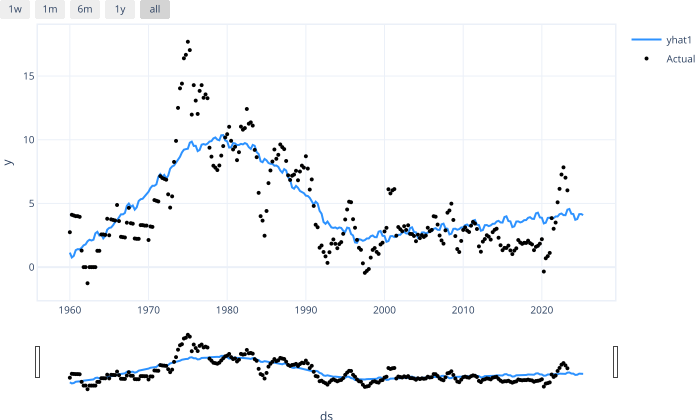

In [47]:
aus_cpi_forecast_visual = aus_cpi_model.plot(aus_cpi_forecast)

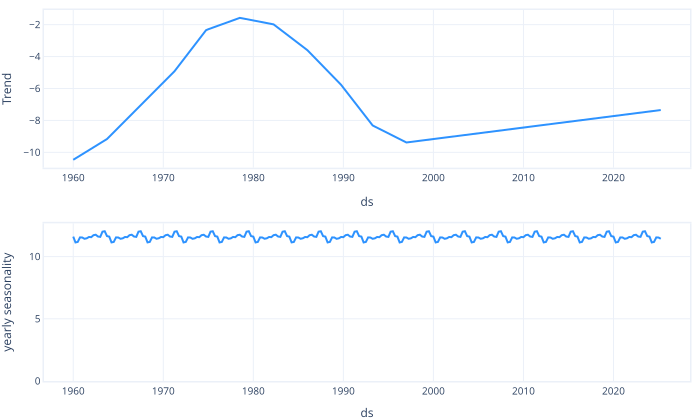

In [48]:
trends_seasons = aus_cpi_model.plot_components(aus_cpi_forecast)

# Using External Regressors - next time we perform causal analysis.